In [138]:
#Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [139]:
#Loading the dataset
mushroom = pd.read_csv('/Users/shraddha/Desktop/MPSA - SHRADDHA GUPTE/Fall 2024 Q3/Data Mining Applications - ALY 6040/Module 2/Copy of mushrooms.csv')

In [140]:
#str of the data 
mushroom_str = str(mushroom)
mushroom_str
print(mushroom.head())
print(mushroom.describe())
print(mushroom.isnull().sum())
print(mushroom.groupby('class').size())

  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

In [141]:
# number of rows with missing values
num_missing_rows = len(mushroom) - mushroom.dropna().shape[0]

In [146]:
# deleting redundant variable `veil-type`
mushroom.drop('veil-type', axis=1, inplace=True)

In [147]:
#analyzing the odor variable
contingency_table = pd.crosstab(mushroom['class'], mushroom['odor'])
print(contingency_table)

def perfect_splits(col):
    t = pd.crosstab(mushroom['class'], col)
    return np.sum(t.values == 0)

# Apply the function to all columns except the first
number_perfect_splits = mushroom.iloc[:, 1:].apply(perfect_splits, axis=0)

print(number_perfect_splits)

odor     a    c     f    l   m     n    p    s    y
class                                              
e      400    0     0  400   0  3408    0    0    0
p        0  192  2160    0  36   120  256  576  576
cap-shape                   2
cap-surface                 1
cap-color                   2
bruises                     0
odor                        8
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  4
stalk-shape                 0
stalk-root                  1
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      6
stalk-color-below-ring      6
veil-color                  3
ring-number                 1
ring-type                   3
spore-print-color           5
population                  2
habitat                     1
dtype: int64


In [150]:
# Descending order of perfect splits
sorted_number_perfect_splits = number_perfect_splits.sort_values(ascending=False)

# The result is already ordered, so no need to use a separate order variable
print(sorted_number_perfect_splits)


odor                        8
stalk-color-above-ring      6
stalk-color-below-ring      6
spore-print-color           5
gill-color                  4
ring-type                   3
veil-color                  3
cap-shape                   2
cap-color                   2
population                  2
ring-number                 1
stalk-root                  1
cap-surface                 1
habitat                     1
stalk-surface-below-ring    0
stalk-surface-above-ring    0
stalk-shape                 0
gill-size                   0
gill-spacing                0
gill-attachment             0
bruises                     0
dtype: int64


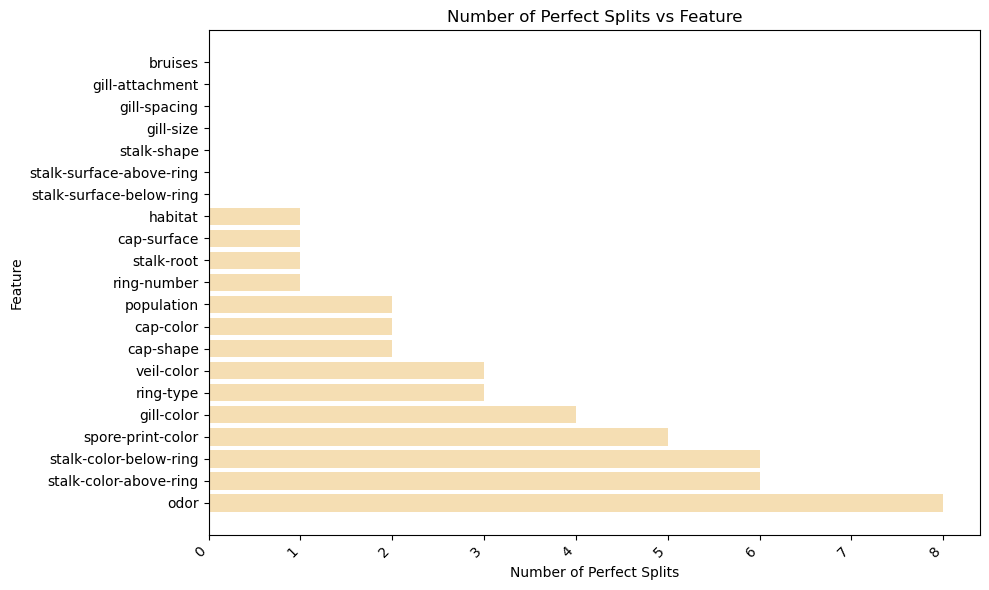

In [152]:
# Plot graph
import matplotlib.pyplot as plt

# Adjust margins 
plt.figure(figsize=(10, 6)) 

# Create the bar plot
plt.barh(sorted_number_perfect_splits.index, sorted_number_perfect_splits, color='wheat')

# Add labels and title
plt.title('Number of Perfect Splits vs Feature')
plt.xlabel('Number of Perfect Splits')
plt.ylabel('Feature')

# Rotate x-axis labels (similar to las=2 in R, which rotates labels)
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.tight_layout()  
plt.show()


In [154]:
#data splicing
# Set the random seed for reproducibility
np.random.seed(12345)

# Determine the number of rows for training (80% of the dataset)
train_size = int(np.ceil(0.80 * len(mushroom)))

# Randomly sample row indices for the training set
train_indices = np.random.choice(mushroom.index, size=train_size, replace=False)

# Split the dataset into training and test sets
mushroom_train = mushroom.loc[train_indices]
mushroom_test = mushroom.drop(train_indices)

print(f"Training set size: {mushroom_train.shape}")
print(f"Test set size: {mushroom_test.shape}")

Training set size: (6500, 22)
Test set size: (1624, 22)


In [156]:
#Penalty Matrix
penalty_matrix = np.array([[0, 1], [10, 0]])

print(penalty_matrix)

[[ 0  1]
 [10  0]]


In [158]:
# building the classification tree with rpart
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

label_encoders = {}
for column in mushroom_train.columns:
    le = LabelEncoder()
    mushroom_train[column] = le.fit_transform(mushroom_train[column])
    label_encoders[column] = le
for column in mushroom_test.columns:
    mushroom_test[column] = label_encoders[column].transform(mushroom_test[column])

# Create and fit the decision tree classifier
tree = DecisionTreeClassifier(random_state=12345)

In [160]:
# Visualize the decision tree with rpart.plot
param_grid = {'max_depth': np.arange(1, 21)}  # Adjust the range as necessary
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='accuracy')
grid_search.fit(mushroom_train.drop(columns=['class']), mushroom_train['class'])
if hasattr(grid_search, 'best_params_'):
    best_max_depth = grid_search.best_params_['max_depth']
else:
    print("Grid search did not complete successfully.")
    best_max_depth = None


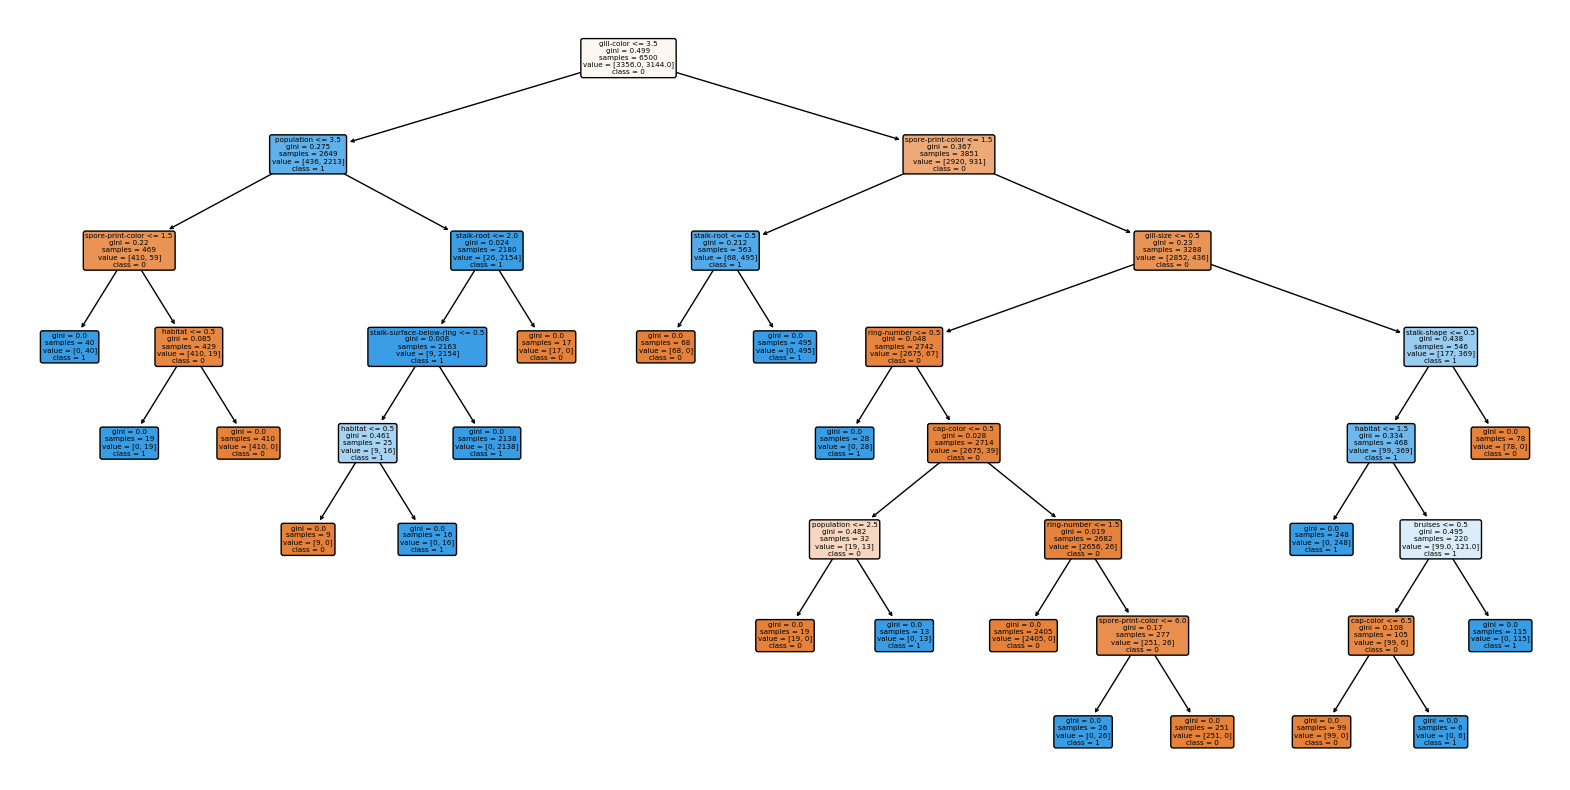

In [162]:
# choosing the best complexity parameter "cp" to prune the tree
if best_max_depth is not None:
    tree = DecisionTreeClassifier(random_state=12345, max_depth=best_max_depth)
    tree.fit(mushroom_train.drop(columns=['class']), mushroom_train['class'])

    # Visualize the decision tree
    plt.figure(figsize=(20, 10))
    plot_tree(tree, filled=True, feature_names=mushroom_train.columns[1:], 
              class_names=np.unique(mushroom_train['class']).astype(str), rounded=True)
    plt.show()


In [164]:
#Testing the model
pred = tree.predict(mushroom_test.drop(columns=['class']))


In [166]:
#Calculating accuracy
accuracy = accuracy_score(mushroom_test['class'], pred)
conf_matrix = confusion_matrix(mushroom_test['class'], pred)
  
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Best max depth not found; cannot fit and test the model.")

Accuracy: 1.0
Confusion Matrix:
[[852   0]
 [  0 772]]
Best max depth not found; cannot fit and test the model.
